In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # for making plots with seaborn
color = sns.color_palette()
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

In [3]:
import io

In [4]:
uploaded = files.upload()

Saving Market_Risk_Data_coded.csv to Market_Risk_Data_coded.csv


In [6]:
stock_prices = pd.read_csv(io.StringIO(uploaded['Market_Risk_Data_coded.csv'].decode('utf-8')))

# PART B: Stock Price Graph Analysis
- Draw a Stock Price Graph (Stock Price vs Time) for the given stocks - Write observations


In [7]:
#Glimpse of Data
stock_prices.head()

,Date,ITC Limited,Bharti Airtel,Tata Motors,DLF Limited,Yes Bank
0,28-03-2016,217,316,386,114,173
1,04-04-2016,218,302,386,121,171
2,11-04-2016,215,308,374,120,171
3,18-04-2016,223,320,408,122,172
4,25-04-2016,214,319,418,122,175


In [8]:
stock_prices.columns = stock_prices.columns.str.replace(' ', '_').str.replace('.', '')

In [9]:
stock_prices.head()

,Date,ITC_Limited,Bharti_Airtel,Tata_Motors,DLF_Limited,Yes_Bank
0,28-03-2016,217,316,386,114,173
1,04-04-2016,218,302,386,121,171
2,11-04-2016,215,308,374,120,171
3,18-04-2016,223,320,408,122,172
4,25-04-2016,214,319,418,122,175


In [10]:
print('The number of rows (observations) is',stock_prices.shape[0],'\n''The number of columns (variables) is',stock_prices.shape[1])

The number of rows (observations) is 418 
The number of columns (variables) is 6


In [11]:
stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           418 non-null    object
 1   ITC_Limited    418 non-null    int64 
 2   Bharti_Airtel  418 non-null    int64 
 3   Tata_Motors    418 non-null    int64 
 4   DLF_Limited    418 non-null    int64 
 5   Yes_Bank       418 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 19.7+ KB


## Lets us plot & see price trend over time for different companies

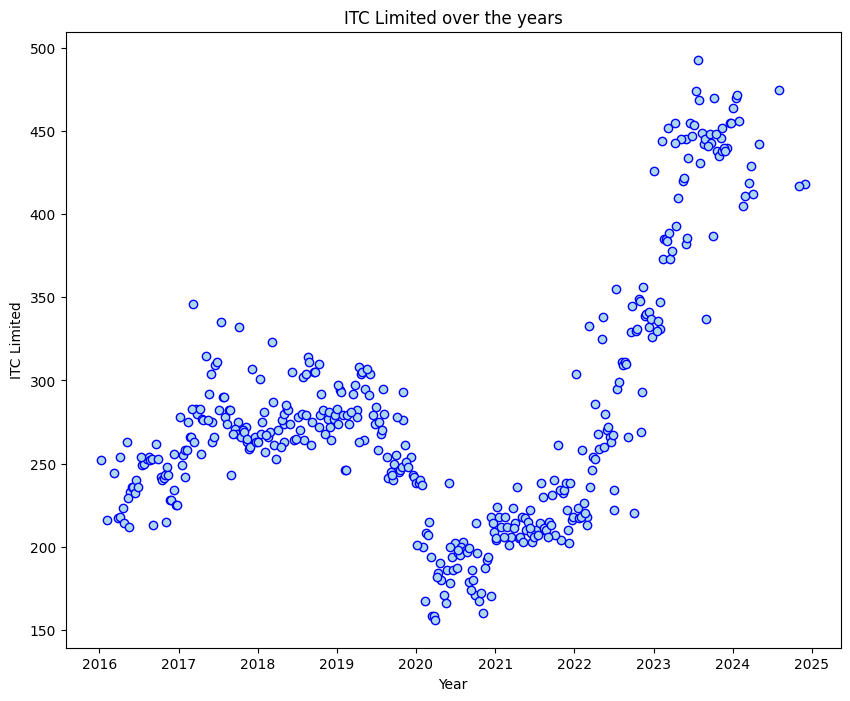

In [14]:
plt.figure(figsize = (10, 8))
stock_prices['dates'] = [pd.to_datetime(d) for d in stock_prices['Date']]
plt.scatter(stock_prices['dates'], stock_prices['ITC_Limited'], edgecolors='b', color = 'lightblue')
plt.xlabel('Year')
plt.ylabel('ITC Limited')
plt.title('ITC Limited over the years')
plt.show()

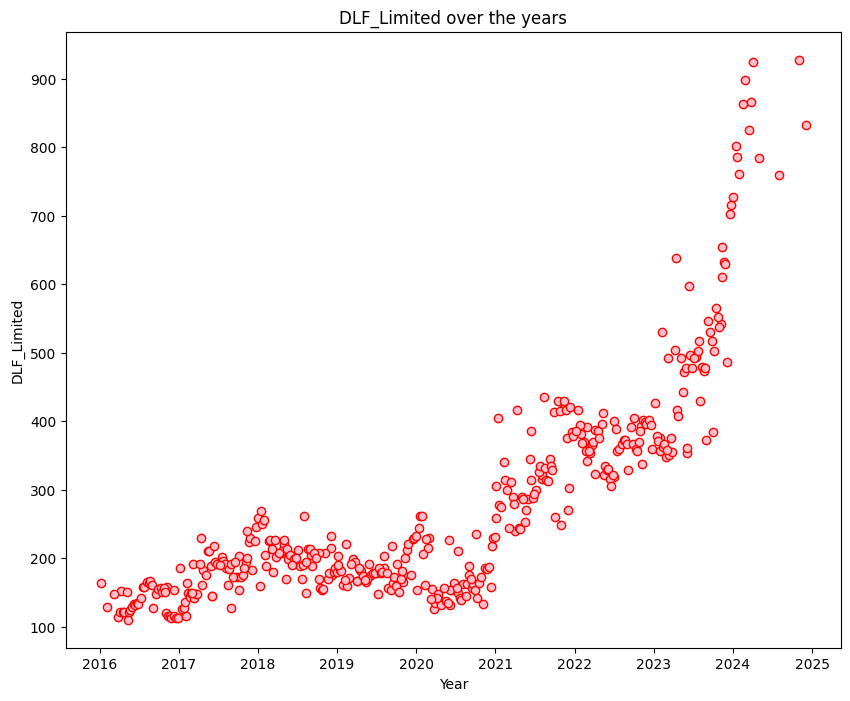

In [15]:
plt.figure(figsize = (10, 8))
stock_prices['dates'] = [pd.to_datetime(d) for d in stock_prices['Date']]
plt.scatter(stock_prices['dates'], stock_prices['DLF_Limited'], edgecolors='r', color = 'pink')
plt.xlabel('Year')
plt.ylabel('DLF_Limited')
plt.title('DLF_Limited over the years')
plt.show()

# PART B: Stock Returns Calculation and Analysis
- Calculate Returns for all stocks - Calculate the Mean and Standard Deviation for the returns of all stocks - Draw a plot of Mean vs Standard Deviation for all stock returns - Write observations and inferences


In [16]:
stock_returns = np.log(stock_prices.drop(['Date','dates'],axis=1)).diff(axis = 0, periods = 1)

In [17]:
stock_returns.head()

,ITC_Limited,Bharti_Airtel,Tata_Motors,DLF_Limited,Yes_Bank
0,NaN,NaN,NaN,NaN,NaN
1,0.004598,-0.045315,0.000000,0.059592,-0.011628
2,-0.013857,0.019673,-0.031582,-0.008299,0.000000
3,0.036534,0.038221,0.087011,0.016529,0.005831
4,-0.041196,-0.003130,0.024214,0.000000,0.017291


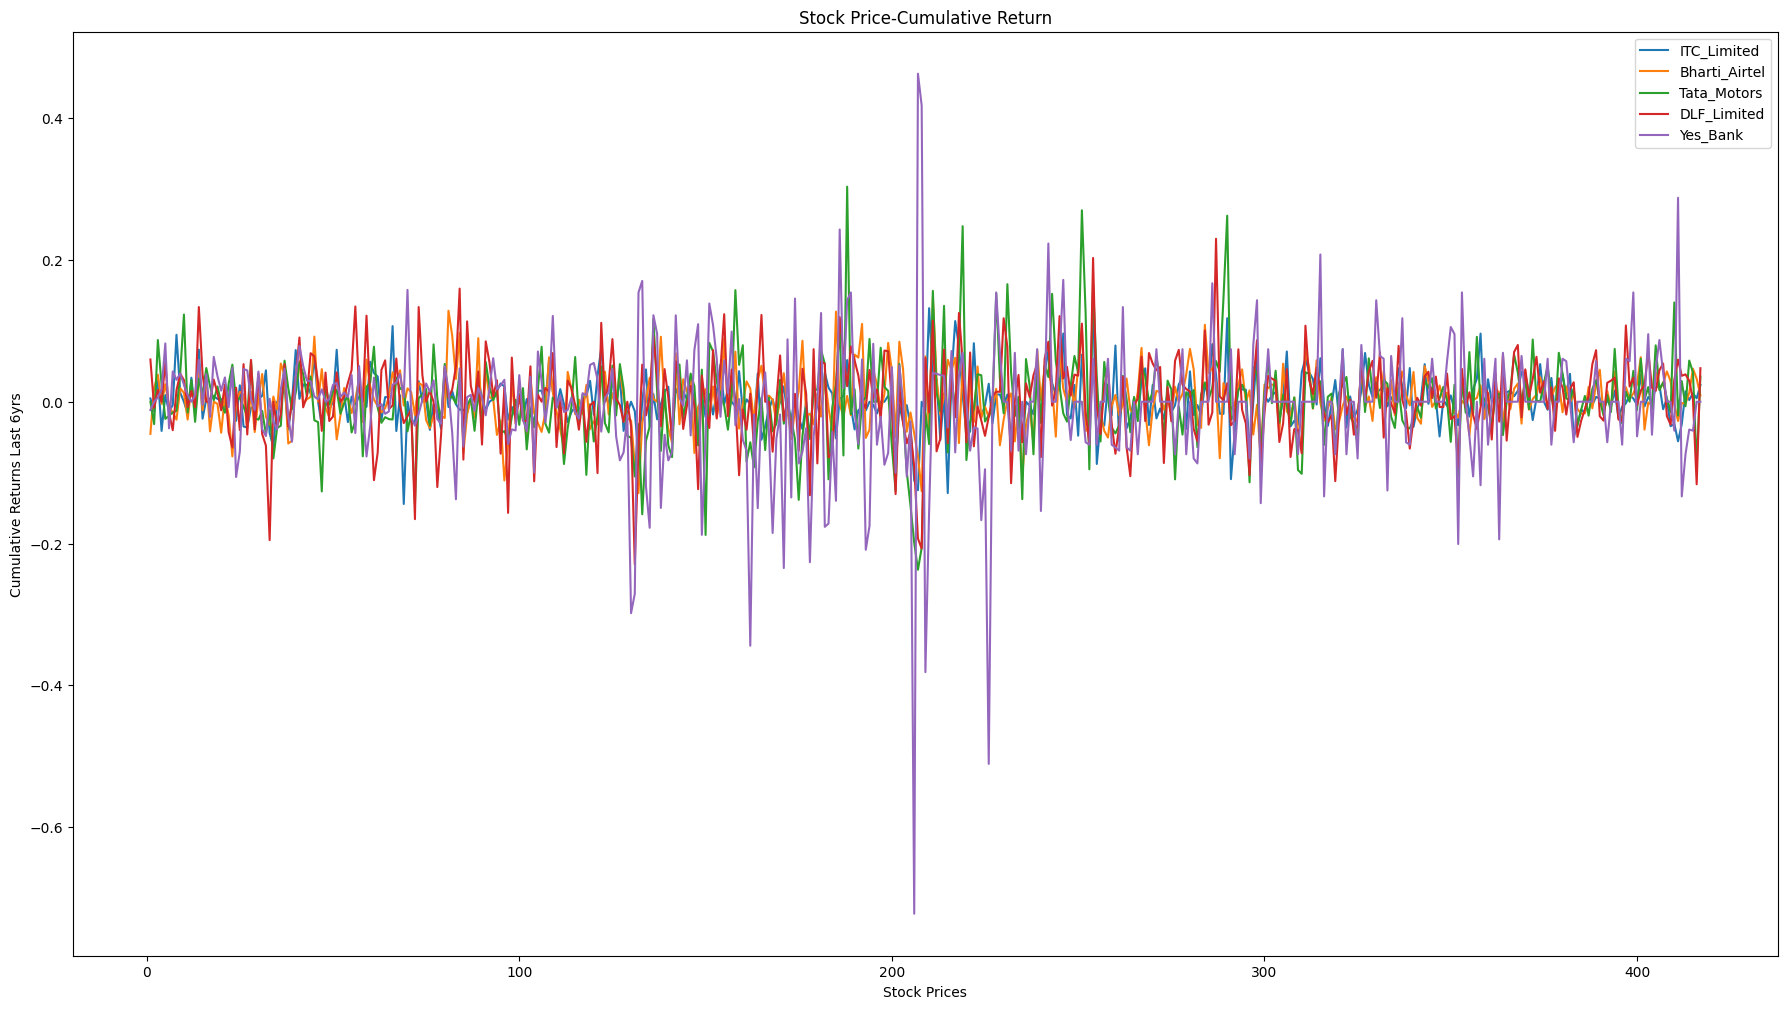

In [27]:
stock_returns.plot(figsize=(22,12))
plt.xlabel("Stock Prices")
plt.ylabel("Cumulative Returns Last 6yrs")
plt.title("Stock Price-Cumulative Return")
plt.show()

### We now look at Means & Standard Deviations of these returns

- Stock Means: Average returns that the stock is making on a week to week basis
- Stock Standard Deviation : It is a measure of volatility meaning the more a stock's returns vary from the stock's average return, the more volatile the stock

In [18]:
#### Calculating stock means

In [19]:
stock_means = stock_returns.mean(axis = 0)
stock_means

ITC_Limited      0.001634
Bharti_Airtel    0.003271
Tata_Motors      0.002234
DLF_Limited      0.004863
Yes_Bank        -0.004737
dtype: float64

In [20]:
#### Calculating stock standard deviation

In [21]:
stock_sd = stock_returns.std(axis = 0)
stock_sd

ITC_Limited      0.035904
Bharti_Airtel    0.038728
Tata_Motors      0.060484
DLF_Limited      0.057785
Yes_Bank         0.093879
dtype: float64

In [31]:
# Calculating Stock Mean as Average

In [28]:
df=pd.DataFrame({'Average':stock_means,'Volatility': stock_sd})
df.sort_values(by=['Average'],ascending=False)

,Average,Volatility
DLF_Limited,0.004863,0.057785
Bharti_Airtel,0.003271,0.038728
Tata_Motors,0.002234,0.060484
ITC_Limited,0.001634,0.035904
Yes_Bank,-0.004737,0.093879


In [29]:
#Calculating Stock Standard Deviation as Volatility

In [30]:
df=pd.DataFrame({'Average':stock_means,'Volatility': stock_sd})
df.sort_values(by=['Volatility'],ascending=False)

,Average,Volatility
Yes_Bank,-0.004737,0.093879
Tata_Motors,0.002234,0.060484
DLF_Limited,0.004863,0.057785
Bharti_Airtel,0.003271,0.038728
ITC_Limited,0.001634,0.035904


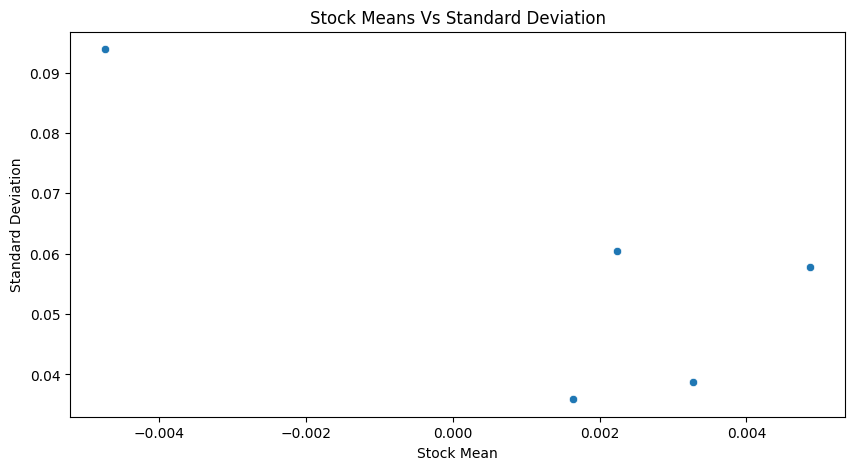

In [33]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Average'], y=df['Volatility'], palette="deep")
plt.ylabel("Standard Deviation")
plt.xlabel("Stock Mean")
plt.title("Stock Means Vs Standard Deviation")
plt.show()

In [26]:
df_positive =df['Average'] > 0
df_positive

ITC_Limited       True
Bharti_Airtel     True
Tata_Motors       True
DLF_Limited       True
Yes_Bank         False
Name: Average, dtype: bool

# The End